# 2. A Short Tour of the Predictive Modeling Process

---
🧠 *This is a learning version with code cells emptied. Read the instructions in each cell, then write the code yourself. Peek at the original notebook if you get stuck.*

Introduce the broad concepts of modeling building, i.e. building candidate models and selecting the optimal model.

## 2.1 Case Study: Predicting Fuel Economy

Check if data exists:

In [1]:
# 🧠 TIP: The '!' lets you run shell commands from a notebook.
# This lists files in the FuelEconomy dataset directory.
# Relative path '../datasets/FuelEconomy/' means: go up one folder from
# the 'notebooks/' directory, then into datasets/FuelEconomy/

!ls -l ../datasets/FuelEconomy/


total 280
-rw-r--r--  1 larrygrpolanco  staff  106388 Jun 17 10:40 cars2010.csv
-rw-r--r--  1 larrygrpolanco  staff   23219 Jun 17 10:40 cars2011.csv
-rw-r--r--  1 larrygrpolanco  staff    8969 Jun 17 10:40 cars2012.csv


In this study, we are only interested in data from 2010 and 2011. Use the DataFrame data type from **pandas** to store the files. It is very similar to the statistical package **R**'s data frame.

🧠 **DataFrame 101:** A DataFrame is a table of data. **Rows** = observations (individual cars). **Columns** = features/predictors (attributes like engine size, cylinders, etc.). It's like a spreadsheet or SQL table.

In [3]:
# 🧠 TIP: pandas is the go-to library for data manipulation in Python.
#   pd.read_csv() loads a CSV file into a DataFrame.
#   numpy (imported as np) adds math & array operations.
#
# 🔑 KEY VOCAB:
#   - X (features) = what you use TO make predictions
#   - y (target)   = what you WANT to predict
#   - training data = the data you show the model to learn from
#   - test data     = held-out data to evaluate the model honestly
#
# TODO: import numpy (as np), import pandas (as pd)
# TODO: read '../datasets/FuelEconomy/cars2010.csv' into a variable called 'cars10'
# TODO: read '../datasets/FuelEconomy/cars2011.csv' into a variable called 'cars11'

import numpy as np
import pandas as pd

cars10 = pd.read_csv("../datasets/FuelEconomy/cars2010.csv")
cars11 = pd.read_csv("../datasets/FuelEconomy/cars2011.csv")

Let's look at the first few rows to understand the structure.

In [4]:
# 🧠 TIP: .head(n) shows the first n rows. Great for a quick sanity check.
#   .head()  → first 5 rows (default)
#   .head(10) → first 10 rows
#
# 🔑 Notice the columns: EngDispl (engine displacement), NumCyl (cylinders),
#   FE (fuel efficiency - our target!), Transmission, etc.
#   We have 15 columns total.
#
# TODO: call cars10.head(5) to preview the data

cars10.head(10)


,Unnamed: 0,EngDispl,NumCyl,Transmission,FE,AirAspirationMethod,NumGears,TransLockup,TransCreeperGear,DriveDesc,IntakeValvePerCyl,ExhaustValvesPerCyl,CarlineClassDesc,VarValveTiming,VarValveLift
0,1088,4.7,8,AM6,28.0198,NaturallyAspirated,6,1.0,0.0,TwoWheelDriveRear,2,2,2Seaters,1.0,0.0
1,1089,4.7,8,M6,25.6094,NaturallyAspirated,6,1.0,0.0,TwoWheelDriveRear,2,2,2Seaters,1.0,0.0
2,1090,4.2,8,M6,26.8000,NaturallyAspirated,6,1.0,0.0,AllWheelDrive,2,2,2Seaters,1.0,0.0
3,1091,4.2,8,AM6,25.0451,NaturallyAspirated,6,1.0,0.0,AllWheelDrive,2,2,2Seaters,1.0,0.0
4,1092,5.2,10,AM6,24.8000,NaturallyAspirated,6,0.0,0.0,AllWheelDrive,2,2,2Seaters,1.0,0.0
5,1093,5.2,10,M6,23.9000,NaturallyAspirated,6,0.0,0.0,AllWheelDrive,2,2,2Seaters,1.0,0.0
6,1094,2.0,4,S6,39.7256,Turbocharged,6,0.0,0.0,AllWheelDrive,2,2,2Seaters,1.0,0.0
7,1095,6.0,12,S6,24.4000,Turbocharged,6,0.0,0.0,AllWheelDrive,2,2,2Seaters,1.0,0.0
8,1096,3.0,6,S6,39.7103,NaturallyAspirated,6,1.0,0.0,TwoWheelDriveRear,2,2,2Seaters,1.0,1.0
9,1097,3.0,6,M6,38.7896,NaturallyAspirated,6,0.0,0.0,TwoWheelDriveRear,2,2,2Seaters,1.0,1.0


Check if there is any missing values 'NaN' in this dataset.

In [5]:
# 🧠 TIP: .count() returns the number of NON-NULL values in each column.
#   If every column has the same count, there are no missing values.
#   Missing data is common in real-world datasets and needs handling.
#
# TODO: call cars10.count() to see non-null counts per column

cars10.count()

Unnamed: 0             1107
EngDispl               1107
NumCyl                 1107
Transmission           1107
FE                     1107
AirAspirationMethod    1107
NumGears               1107
TransLockup            1107
TransCreeperGear       1107
DriveDesc              1107
IntakeValvePerCyl      1107
ExhaustValvesPerCyl    1107
CarlineClassDesc       1107
VarValveTiming         1107
VarValveLift           1107
dtype: int64

In [6]:
# 🧠 TIP: .shape returns a tuple: (number_of_rows, number_of_columns)
#   cars10.shape → (1107, 15) means 1107 cars, 15 attributes
#
# TODO: print the shape of cars10 and cars11

print(cars10.shape)
print(cars11.shape)



(1107, 15)
(245, 15)


We only restrict ourselves to a single predictor 'EngDispl' and the response 'FE' in this introductory illustration.

In [7]:
# 🧠 TIP: We split the data into:
#   - cars10_feature (X): the input/predictor (Engine Displacement)
#   - cars10_target  (y): the output/response (Fuel Efficiency)
#
# We use double brackets df[['col']] to keep it as a DataFrame (2D).
# Single brackets df['col'] would give a Series (1D) - sklearn prefers 2D.
#
# 🔑 Think of it like: given engine size (X), can we predict MPG (y)?
#
# TODO: Use .get() or .loc[] to select 'EngDispl' as the feature for 2010
# TODO: Select 'FE' as the target for 2010
# TODO: Do the same for 2011 data

cars10_features = cars10.get(['EngDispl'])
cars10_targets = cars10.get(["FE"])
cars11_features = cars11.get(["EngDispl"])
cars11_targets = cars11.get(["FE"])

In [8]:
# 🧠 TIP: Verify the split worked correctly
# TODO: display the first 5 rows of cars10_feature

print(cars10_features.head())

   EngDispl
0       4.7
1       4.7
2       4.2
3       4.2
4       5.2


In [9]:
# TODO: display the first 5 rows of cars10_target

print(cars10_targets.head())

        FE
0  28.0198
1  25.6094
2  26.8000
3  25.0451
4  24.8000


Generally, we want to first visualize the datasets to get a better understanding before doing anything crazy. Since there is one predictor, a simple scatter plot would do the trick. The characteristics from the visualization may suggest important and necessary pre-processing steps.

🧠 **EDA (Exploratory Data Analysis)**: Always look at your data before modeling! Plots reveal patterns, outliers, and relationships that numbers alone hide.

In [11]:
# 🧠 TIP: matplotlib is the standard plotting library.
#   %matplotlib inline makes plots appear right in the notebook.
#   plt.rcParams sets global defaults for all plots.
#
# TODO: set up matplotlib inline, import pyplot as plt
# TODO: set figure size to (10, 7.5) and enable grid

%matplotlib inline
import matplotlib.pyplot as plt

plt.rcParams['figure.figsize'] = 10, 7.5
plt.rcParams['axes.grid'] = True
plt.gray()


<Figure size 1000x750 with 0 Axes>

Text(0.5, 1.0, '2011 Model Year')

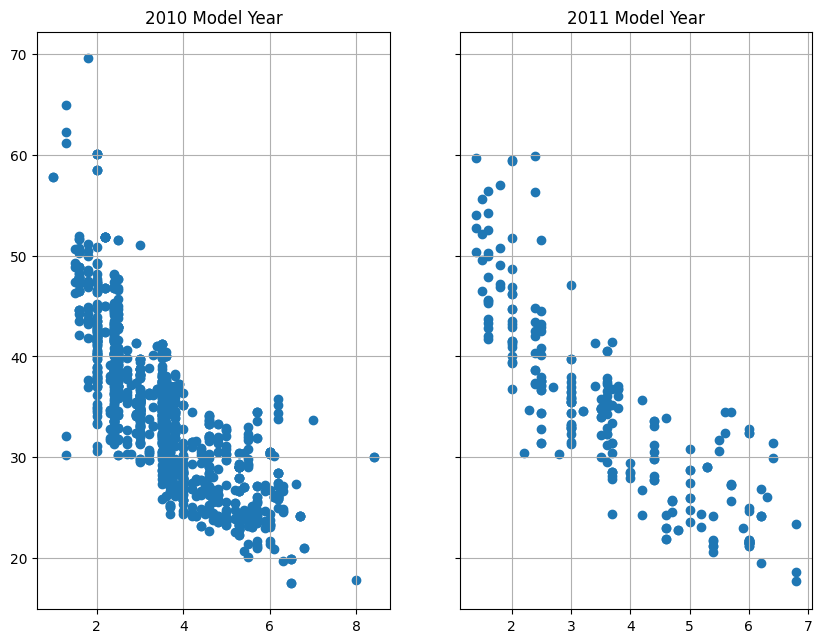

In [13]:
# 🧠 TIP: plt.subplots(1, 2) creates 1 row, 2 columns of plots side-by-side.
#   sharey=True makes them share the same y-axis scale for easy comparison.
#   'fig' is the whole figure, 'ax1'/'ax2' are the individual subplot areas.
#
# TODO: create a 1x2 grid of subplots with shared y-axis
# TODO: scatter plot of cars10_feature vs cars10_target on ax1
# TODO: scatter plot of cars11_feature vs cars11_target on ax2
# TODO: add titles, x-label, and y-label


fig, (ax1, ax2) = plt.subplots(1, 2, sharey=True)

ax1.scatter(cars10_features, cars10_targets)
ax1.set_title("2010 Model Year")
ax2.scatter(cars11_features, cars11_targets)
ax2.set_title("2011 Model Year")

Because of the nature of this problem, i.e. predict the MPG for a new car line, we take the 2010 data as *training set* and the 2011 data as *test set*.

🧠 **Why separate train/test?** If we evaluate on the same data we trained on, the model looks better than it really is (overfitting). The test set simulates "new, unseen data" and gives an honest performance estimate.

In [ ]:
# 🧠 TIP: RMSE = Root Mean Squared Error
#   Formula: sqrt( mean( (actual - predicted)^2 ) )
#   It measures how far off our predictions are, on average.
#   Lower RMSE = better predictions.
#   Units: same as the target (MPG in this case).
#
#   sklearn.metrics.mean_squared_error() computes MSE for us.
#   We wrap it in np.sqrt() to get RMSE.
#
# TODO: import mean_squared_error from sklearn.metrics
# TODO: define a function rmse(y_actual, y_predicted)

from sklearn.metrics import mean_squared_error

def rmse(y_actual, y_predicted):
  return np.sqrt(mean_squared_error(y_actual, y_predicted))

A good starting point is the simple linear model 
$$y = \beta_0 + \beta_1x,$$
where $y$ is the Fuel Efficiency (MPG) and $x$ is the Engine Displacement.

🧠 **Linear Regression:** Finds the "best fit" straight line through the data.
  - $\beta_0$ (intercept) = predicted MPG when engine displacement is 0
  - $\beta_1$ (coefficient) = change in MPG for each 1L increase in displacement
  - "Fitting" = finding the values of $\beta_0$ and $\beta_1$ that minimize RMSE

In [16]:
# 🧠 TIP: sklearn uses a consistent API:
#   1. Create the model: model = LinearRegression()
#   2. Train (fit):      model.fit(X, y)
#   3. Predict:          model.predict(X_new)
#
#   model.intercept_ and model.coef_ store the learned parameters.
#
# TODO: import LinearRegression from sklearn.linear_model
# TODO: create a LinearRegression model, fit it on cars10_feature + cars10_target
# TODO: print intercept_ and coef_

from sklearn.linear_model import LinearRegression 

linear_model = LinearRegression()
linear_model.fit(cars10_features, cars10_targets)
print(linear_model.intercept_)
print(linear_model.coef_)

[50.56322991]
[[-4.52092928]]


In [ ]:
# 🧠 TIP: Plot the fitted line over the data to see how well it matches.
#   np.linspace() creates evenly spaced values for a smooth line.
#   [:, np.newaxis] reshapes it from 1D to 2D column (sklearn expects 2D).
#   The red line shows the model's predictions across all engine sizes.
#   The right plot compares observed vs predicted - perfect predictions
#   would fall on the dashed diagonal line.
#
# TODO: generate a smooth range of X values for plotting the line
# TODO: call predict() on both the smooth range and training data
# TODO: create side-by-side plots: data+line, and observed vs predicted






The left-hand panel shows the training set data with a linear model fit defined by the estimated slope and intercept. The right-hand panel plots the observed and predicted MPG. These plots demonstrate that this model misses some of the patterns in the data, such as under-predicting fuel efficiency when the displacement is less than 2L or above 6L

🧠 **What this tells us:** The relationship isn't perfectly straight. We need a more flexible model.

In [ ]:
# 🧠 TIP: cross_val_score performs K-fold cross-validation automatically.
#   cv=10 means: split data into 10 folds, train on 9, test on 1, repeat 10x.
#   This gives 10 different RMSE scores, then we average them.
#   It's more reliable than a single train/test split.
#
#   sklearn returns NEGATIVE MSE (because scoring='maximize' by convention),
#   so we take np.abs() before sqrt.
#
#   WARNING: This is a simplified use of cross_val_score - in practice you'd
#   not do CV on the test set. Here they use it on training set for estimation.
#
# TODO: import cross_val_score from sklearn.model_selection
# TODO: compute 10-fold cross-validated RMSE for the linear model
# TODO: print the average RMSE




**Notice** that simply re-predicting the training set data is likely to result in overly optimistic estimation of RMSE. An alternative approach for quantifying how well the model operates is to use *resampling* techniques, e.g. 10-fold cross-validation. We will cover that in Chapter 4.

🧠 **Overfitting:** A model that memorizes the training data but fails on new data. CV helps detect this.

Looking at the previous figure, it is conceivable that the problem might be solved by introducing some non-linearity in the model. The most basic approach is to supplement the simple linear model with additional complexity, e.g.
$$y = \beta_0 + \beta_1 x + \beta_2 x^2,$$
which is referred to as *quadratic model*.

🧠 **Why add x²?** The scatter plot looked curved. A straight line can't capture curves, but adding x² (a parabola) adds flexibility. More terms = more flexible = risk of overfitting.

In [ ]:
# 🧠 TIP: Pipeline chains multiple steps together.
#   make_pipeline(PolynomialFeatures(2), LinearRegression()) means:
#   1. First transform X to include x² (and x¹, x⁰ as intercept)
#   2. Then fit a linear regression on those transformed features
#
#   PolynomialFeatures(2) creates: [1, x, x²]
#   The linear regression then fits: y = b0 + b1*x + b2*x²
#
#   The pipeline can be used just like a regular model: .fit(), .predict()
#
# TODO: import PolynomialFeatures and make_pipeline
# TODO: create a pipeline with degree-2 polynomial + linear regression
# TODO: fit it and compute cross-validated RMSE





Reduction in RMSE suggests that this model is a better fit to the data.

In [ ]:
# 🧠 TIP: Same plotting pattern as before, but for the quadratic model.
#   Notice how the red line is now curved to follow the data better.
#
# TODO: plot the quadratic model's fit (data + curve + observed vs predicted)






One issue with quadratic models is that they can perform poorly on the extremes of the predictor. From the above figure, one might notice that predicting new vehicles with large displacement values may produce inaccurate results.

🧠 **The parabola problem:** A quadratic curve always turns around. If the data only goes up to 8L but you predict for a 10L engine, the parabola might shoot up or down unrealistically.

There are other approaches for creating sophisticated relationships between the predictors and outcome. One particular technique is the multivariate adaptive regression spline (MARS) model (Friedman (1991)). When used with a single predictor, MARS can fit separate linear regression lines for different ranges of engine displacement. This model, like many machine learning algorithms, has a *tuning parameter* which cannot be directly estimated from the data. While the MARS model has internal algorithms for making this determination, the user can try different values and use resampling to determine the appropriate value. Once the value is found, a final MARS model would be fit using all the training set data and used for prediction.

🧠 **MARS intuition:** Instead of one global curve, MARS fits several straight lines at different regions (e.g., one slope for small engines, another for large engines). The points where the slope changes are called "knots."

🧠 **Tuning parameters:** These are settings the model can't learn from data alone. You must choose them (by trying values and testing with CV). Examples: degree of polynomial, number of knots in MARS, depth of a decision tree.

A Python module *py-earth* on Github implemented the MARS and is likely to be merged into *sklearn* in the near future (see [this](https://github.com/scikit-learn/scikit-learn/issues/845) issue).

🧠 **Note:** py-earth may not be installed. If you get an import error, you can skip this cell or install it with `pip install py-earth`. The important learning is the *concept* of MARS, not the specific library.

In [ ]:
# 🧠 TIP: MARS fits piecewise linear segments.
#   Earth() is the MARS implementation from py-earth.
#   Like sklearn models, it uses .fit() and .predict().
#   Its RMSE here is similar to the quadratic model.
#
# TODO: import Earth from pyearth
# TODO: create a MARS model, fit it, compute CV RMSE




RMSE of MARS is similar to that of quadratic regression.

In [ ]:
# TODO: plot the MARS model's fit (data + curve + observed vs predicted)






Both quadratic model and MARS are evaluated on the test set.

In [ ]:
# 🧠 TIP: This is the REAL test - evaluating on 2011 data (never seen during training).
#   Models were trained on 2010, now we test on 2011. This tells us how they
#   will perform on truly new cars.
#
# TODO: create side-by-side scatter plots showing both models on the 2011 test data






In [ ]:
# 🧠 TIP: Finally, we compute test-set RMSE for both models.
#   Compare these numbers to the training CV RMSE you saw earlier.
#   - If test RMSE is much higher than CV RMSE → possible overfitting
#   - If both models have similar RMSE → either is fine for this task
#
# TODO: compute 10-fold CV RMSE for both models on the 2011 (test) data
# TODO: print both scores




The first thing to notice is that both scores are very similar, which indicates that either model is appropriate for this task.

🧠 **Key Insight:** Sometimes simple models (quadratic) perform just as well as complex ones (MARS). "No Free Lunch" - try multiple approaches!

🧠 **The Full Pipeline Recap:**
  1. Load data (pandas) → understand structure (.head, .shape, .count)
  2. Visualize (matplotlib) → see patterns, detect issues
  3. Split into X (features) and y (target)
  4. Choose a model (LinearRegression, PolynomialFeatures, etc.)
  5. Train (.fit) the model on training data
  6. Evaluate (RMSE + cross-validation) on training data
  7. Pick the best model and test on held-out data
  
  This is the fundamental workflow of supervised machine learning!

## 2.2 Themes

There are several aspects of the model building process that are worth discussing further.

### Data Splitting

- How we allocate data to certain tasks, e.g. model building, evaluating performance?
    - extrapolation: order matters
    - interpolation: a simple random sample of the data
- How much data should be allocated to the training and test sets?
    - small data sets: resampling techniques, i.e. no test set
    - large data sets

🧠 **Why this matters:** If you optimize your model using test set feedback, you'll overfit to the test set too! The test set must be used ONLY ONCE at the very end.

### Predictor Data

Feature selection: the process of determining the minimum set of relevant predictors needed by the model.

🧠 **Curse of dimensionality:** More features ≠ better. Irrelevant features add noise. This is why feature selection matters.

### Estimating Performance

- Quantitative assessments of statistics (using resampling techniques)
- Visualization

🧠 **Always visualize!** A number alone (like RMSE) doesn't tell the full story. A plot can reveal systematic errors.

### Evaluating Several Models

"No Free Lunch" Theorem - Try a wide variety of techniques then determine which model to focus on.

🧠 **No single model is best for all problems.** Always try a few different approaches.

### Model Selection

- between models
- within the same model

Rely on cross-validation and the test set to produce quantitative assessments of the models to make the choice.

🧠 **Two levels of selection:** (1) Which type of model? (linear vs quadratic vs MARS). (2) Within a model, what settings? (polynomial degree, MARS complexity). Both should be guided by CV + test set.

## 2.3 Summary

To get a reliable, trustworthy model for predicting new samples, we must first understand the data and the objective of the modeling.

---
🧠 **Final advice for learning:**
1. Run through this notebook cell by cell, writing every line yourself
2. Experiment! Change the polynomial degree. Add more features. Try different models.
3. Break things on purpose to understand error messages
4. The goal isn't to get the lowest RMSE - it's to understand the *process*